In [3]:
import zipfile
import os

zip_path = r"C:\Users\SPADE\Downloads\archive.zip"

print("ZIP size:", round(os.path.getsize(zip_path) / 1024**3, 2), "GB")

with zipfile.ZipFile(zip_path, "r") as z:
    for f in z.infolist():
        print(
            f.filename,
            "| compressed:",
            round(f.compress_size / 1024**3, 2),
            "GB",
            "| uncompressed:",
            round(f.file_size / 1024**3, 2),
            "GB"
        )

ZIP size: 16.18 GB
1.2.826.0.1.3680043.8.498.10000477131564453926848372798213249270.npz | compressed: 0.0 GB | uncompressed: 0.0 GB
1.2.826.0.1.3680043.8.498.10000638804426494408367014941970083813.npz | compressed: 0.0 GB | uncompressed: 0.0 GB
1.2.826.0.1.3680043.8.498.10001344172545964778532427094848882081.npz | compressed: 0.0 GB | uncompressed: 0.0 GB
1.2.826.0.1.3680043.8.498.10001451031710804784840301648844254892.npz | compressed: 0.0 GB | uncompressed: 0.0 GB
1.2.826.0.1.3680043.8.498.10001478771378979438868923030424928430.npz | compressed: 0.0 GB | uncompressed: 0.0 GB
1.2.826.0.1.3680043.8.498.10002261797060075169053014192535848502.npz | compressed: 0.0 GB | uncompressed: 0.0 GB
1.2.826.0.1.3680043.8.498.10002649128333294739274777073688197429.npz | compressed: 0.0 GB | uncompressed: 0.0 GB
1.2.826.0.1.3680043.8.498.10002854609799107704163984063758739358.npz | compressed: 0.0 GB | uncompressed: 0.0 GB
1.2.826.0.1.3680043.8.498.10002940759939066728493680169552264940.npz | compre

In [4]:
import zipfile
import os

zip_path = r"C:\Users\SPADE\Downloads\archive.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    npz_files = [
        f for f in z.infolist()
        if f.filename.endswith(".npz")
    ]

    print("Number of NPZ files:", len(npz_files))

    sizes_mb = [f.file_size / 1024**2 for f in npz_files]

    print("Smallest file:", round(min(sizes_mb), 2), "MB")
    print("Largest file:", round(max(sizes_mb), 2), "MB")
    print("Average file:", round(sum(sizes_mb) / len(sizes_mb), 2), "MB")
    print(
        "Total uncompressed:",
        round(sum(f.file_size for f in npz_files) / 1024**3, 2),
        "GB"
    )

Number of NPZ files: 24371
Smallest file: 0.13 MB
Largest file: 1.05 MB
Average file: 0.68 MB
Total uncompressed: 16.18 GB


In [5]:
import zipfile
import numpy as np
import io

zip_path = r"C:\Users\SPADE\Downloads\archive.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    npz_files = [
        f for f in z.namelist()
        if f.endswith(".npz")
    ]

    first_file = npz_files[0]

    print("Opening:", first_file)

    with z.open(first_file) as f:
        buffer = io.BytesIO(f.read())

        with np.load(buffer, allow_pickle=False) as data:
            print("Arrays inside:", data.files)

            for name in data.files:
                arr = data[name]

                print("\nArray:", name)
                print("Shape:", arr.shape)
                print("Data type:", arr.dtype)
                print("Dimensions:", arr.ndim)

Opening: 1.2.826.0.1.3680043.8.498.10000477131564453926848372798213249270.npz
Arrays inside: ['data']

Array: data
Shape: (24, 224, 224)
Data type: uint8
Dimensions: 3


In [6]:
import zipfile
import numpy as np
import io
import matplotlib.pyplot as plt

zip_path = r"C:\Users\SPADE\Downloads\archive.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    npz_files = [f for f in z.namelist() if f.endswith(".npz")]

    with z.open(npz_files[0]) as f:
        buffer = io.BytesIO(f.read())

        with np.load(buffer) as npz:
            images = npz["data"]

print("Shape:", images.shape)
print("Minimum pixel:", images.min())
print("Maximum pixel:", images.max())
print("Average pixel:", images.mean())

Shape: (24, 224, 224)
Minimum pixel: 0
Maximum pixel: 252
Average pixel: 24.93749169589711


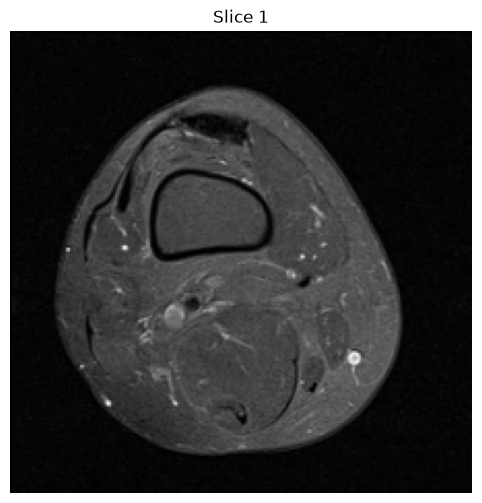

In [7]:
plt.figure(figsize=(6, 6))

plt.imshow(images[0], cmap="gray")
plt.title("Slice 1")
plt.axis("off")

plt.show()

In [8]:
import zipfile
import numpy as np
import pandas as pd
import io

zip_path = r"C:\Users\SPADE\Downloads\archive.zip"

results = []

with zipfile.ZipFile(zip_path, "r") as z:

    npz_files = [
        f for f in z.infolist()
        if f.filename.endswith(".npz")
    ]

    print("Total NPZ files:", len(npz_files))

    for i, file_info in enumerate(npz_files):

        try:
            with z.open(file_info.filename) as f:

                buffer = io.BytesIO(f.read())

                with np.load(buffer, allow_pickle=False) as npz:

                    arr = npz["data"]

                    results.append({
                        "filename": file_info.filename,
                        "slices": arr.shape[0],
                        "height": arr.shape[1],
                        "width": arr.shape[2],
                        "dtype": str(arr.dtype),
                        "min_pixel": int(arr.min()),
                        "max_pixel": int(arr.max()),
                        "mean_pixel": float(arr.mean()),
                        "file_size_mb": round(
                            file_info.file_size / 1024**2, 2
                        ),
                        "status": "OK"
                    })

        except Exception as e:

            results.append({
                "filename": file_info.filename,
                "status": f"ERROR: {e}"
            })

        if (i + 1) % 100 == 0:
            print(f"Processed {i + 1}/{len(npz_files)}")

Total NPZ files: 24371
Processed 100/24371
Processed 200/24371
Processed 300/24371
Processed 400/24371
Processed 500/24371
Processed 600/24371
Processed 700/24371
Processed 800/24371
Processed 900/24371
Processed 1000/24371
Processed 1100/24371
Processed 1200/24371
Processed 1300/24371
Processed 1400/24371
Processed 1500/24371
Processed 1600/24371
Processed 1700/24371
Processed 1800/24371
Processed 1900/24371
Processed 2000/24371
Processed 2100/24371
Processed 2200/24371
Processed 2300/24371
Processed 2400/24371
Processed 2500/24371
Processed 2600/24371
Processed 2700/24371
Processed 2800/24371
Processed 2900/24371
Processed 3000/24371
Processed 3100/24371
Processed 3200/24371
Processed 3300/24371
Processed 3400/24371
Processed 3500/24371
Processed 3600/24371
Processed 3700/24371
Processed 3800/24371
Processed 3900/24371
Processed 4000/24371
Processed 4100/24371
Processed 4200/24371
Processed 4300/24371
Processed 4400/24371
Processed 4500/24371
Processed 4600/24371
Processed 4700/24371

In [9]:
import pandas as pd

df = pd.DataFrame(results)

print("Rows:", len(df))
print(df.head())

Rows: 24371
                                            filename  slices  height  width  \
0  1.2.826.0.1.3680043.8.498.10000477131564453926...      24     224    224   
1  1.2.826.0.1.3680043.8.498.10000638804426494408...      24     224    224   
2  1.2.826.0.1.3680043.8.498.10001344172545964778...      24     224    224   
3  1.2.826.0.1.3680043.8.498.10001451031710804784...      24     224    224   
4  1.2.826.0.1.3680043.8.498.10001478771378979438...      24     224    224   

   dtype  min_pixel  max_pixel  mean_pixel  file_size_mb status  
0  uint8          0        252   24.937492          0.73     OK  
1  uint8          4        251   36.531884          0.71     OK  
2  uint8         11        243   88.671860          0.95     OK  
3  uint8          0        246   46.995652          0.68     OK  
4  uint8          0        253   41.365564          0.60     OK  


In [10]:
df.to_csv("dataset_report.csv", index=False)
print("Saved dataset_report.csv")

Saved dataset_report.csv


In [11]:
print(df["status"].value_counts())

status
OK    24371
Name: count, dtype: int64


In [12]:
print(df["dtype"].value_counts())

dtype
uint8    24371
Name: count, dtype: int64


In [13]:
print(
    df.groupby(["height", "width"])
      .size()
      .sort_values(ascending=False)
      .head(20)
)

height  width
224     224      24371
dtype: int64


In [14]:
print(
    df["slices"]
      .value_counts()
      .sort_index()
)

slices
24    24371
Name: count, dtype: int64


In [15]:
df.sort_values("mean_pixel").head(10)

,filename,slices,height,width,dtype,min_pixel,max_pixel,mean_pixel,file_size_mb,status
11220,1.2.826.0.1.3680043.8.498.35917065377312667007...,24,224,224,uint8,0,253,6.898452,0.13,OK
22329,1.2.826.0.1.3680043.8.498.89837873571047667182...,24,224,224,uint8,0,250,7.064553,0.28,OK
13114,1.2.826.0.1.3680043.8.498.45124382377451388384...,24,224,224,uint8,0,240,7.183845,0.34,OK
22941,1.2.826.0.1.3680043.8.498.92800012200199889737...,24,224,224,uint8,0,248,7.216564,0.32,OK
145,1.2.826.0.1.3680043.8.498.10068571245104766581...,24,224,224,uint8,0,247,7.426549,0.55,OK
4826,1.2.826.0.1.3680043.8.498.12444202866002271459...,24,224,224,uint8,0,247,7.505651,0.37,OK
2819,1.2.826.0.1.3680043.8.498.11429093389811861944...,24,224,224,uint8,0,247,7.616429,0.53,OK
21424,1.2.826.0.1.3680043.8.498.85407847697620587030...,24,224,224,uint8,0,250,7.638037,0.14,OK
14975,1.2.826.0.1.3680043.8.498.54052966555455568825...,24,224,224,uint8,0,248,7.781037,0.29,OK
2378,1.2.826.0.1.3680043.8.498.11214379029766993573...,24,224,224,uint8,0,252,7.843154,0.16,OK


In [16]:
df.sort_values("mean_pixel", ascending=False).head(10)

,filename,slices,height,width,dtype,min_pixel,max_pixel,mean_pixel,file_size_mb,status
10809,1.2.826.0.1.3680043.8.498.33768242062565931148...,24,224,224,uint8,0,255,162.121663,0.61,OK
5672,1.2.826.0.1.3680043.8.498.12869397676148451644...,24,224,224,uint8,0,253,130.159078,1.04,OK
19476,1.2.826.0.1.3680043.8.498.75940149982100115964...,24,224,224,uint8,0,244,129.552461,0.87,OK
14692,1.2.826.0.1.3680043.8.498.52753180293233746385...,24,224,224,uint8,0,254,124.985552,0.75,OK
21957,1.2.826.0.1.3680043.8.498.87918729980231637897...,24,224,224,uint8,0,251,123.667298,1.03,OK
3496,1.2.826.0.1.3680043.8.498.11775596499462328643...,24,224,224,uint8,1,251,123.592739,1.05,OK
20910,1.2.826.0.1.3680043.8.498.83022921455895055965...,24,224,224,uint8,0,253,122.674749,0.90,OK
1578,1.2.826.0.1.3680043.8.498.10799479496416725407...,24,224,224,uint8,0,251,121.977385,0.83,OK
21253,1.2.826.0.1.3680043.8.498.84609387082130830237...,24,224,224,uint8,0,252,121.676478,1.02,OK
20940,1.2.826.0.1.3680043.8.498.83119563715158751970...,24,224,224,uint8,0,252,119.872644,1.04,OK


In [17]:
errors = df[df["status"] != "OK"]

print("Errors:", len(errors))
errors

Errors: 0


,filename,slices,height,width,dtype,min_pixel,max_pixel,mean_pixel,file_size_mb,status


In [18]:
print(df.shape)
print(df["status"].value_counts())
print(df[["slices", "height", "width", "mean_pixel", "file_size_mb"]].describe())

(24371, 10)
status
OK    24371
Name: count, dtype: int64
        slices   height    width    mean_pixel  file_size_mb
count  24371.0  24371.0  24371.0  24371.000000  24371.000000
mean      24.0    224.0    224.0     42.194340      0.679661
std        0.0      0.0      0.0     16.895911      0.122005
min       24.0    224.0    224.0      6.898452      0.130000
25%       24.0    224.0    224.0     29.691264      0.600000
50%       24.0    224.0    224.0     40.485643      0.680000
75%       24.0    224.0    224.0     53.055387      0.760000
max       24.0    224.0    224.0    162.121663      1.050000


In [19]:
Q1 = df["mean_pixel"].quantile(0.25)
Q3 = df["mean_pixel"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower threshold:", lower)
print("Upper threshold:", upper)

outliers = df[
    (df["mean_pixel"] < lower) |
    (df["mean_pixel"] > upper)
]

print("Possible outliers:", len(outliers))

outliers[
    ["filename", "mean_pixel", "min_pixel", "max_pixel"]
].sort_values("mean_pixel")

Lower threshold: -5.354920056401454
Upper threshold: 88.1015714269106
Possible outliers: 228


,filename,mean_pixel,min_pixel,max_pixel
2856,1.2.826.0.1.3680043.8.498.11450104052174533941...,88.116862,0,244
5355,1.2.826.0.1.3680043.8.498.12707440311028479852...,88.161579,0,251
8415,1.2.826.0.1.3680043.8.498.22118441735689162564...,88.187651,0,252
13885,1.2.826.0.1.3680043.8.498.48867926226552814715...,88.197622,6,245
23123,1.2.826.0.1.3680043.8.498.93670395223792512293...,88.202366,0,227
...,...,...,...,...
21957,1.2.826.0.1.3680043.8.498.87918729980231637897...,123.667298,0,251
14692,1.2.826.0.1.3680043.8.498.52753180293233746385...,124.985552,0,254
19476,1.2.826.0.1.3680043.8.498.75940149982100115964...,129.552461,0,244
5672,1.2.826.0.1.3680043.8.498.12869397676148451644...,130.159078,0,253


In [20]:
print(
    round(
        len(outliers) / len(df) * 100,
        2
    ),
    "% of dataset"
)

0.94 % of dataset


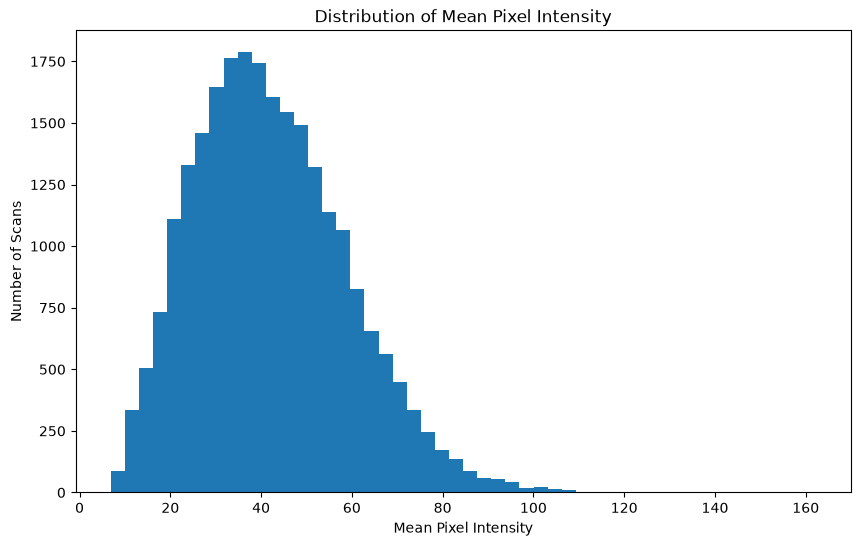

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    df["mean_pixel"],
    bins=50
)

plt.xlabel("Mean Pixel Intensity")
plt.ylabel("Number of Scans")
plt.title("Distribution of Mean Pixel Intensity")

plt.show()

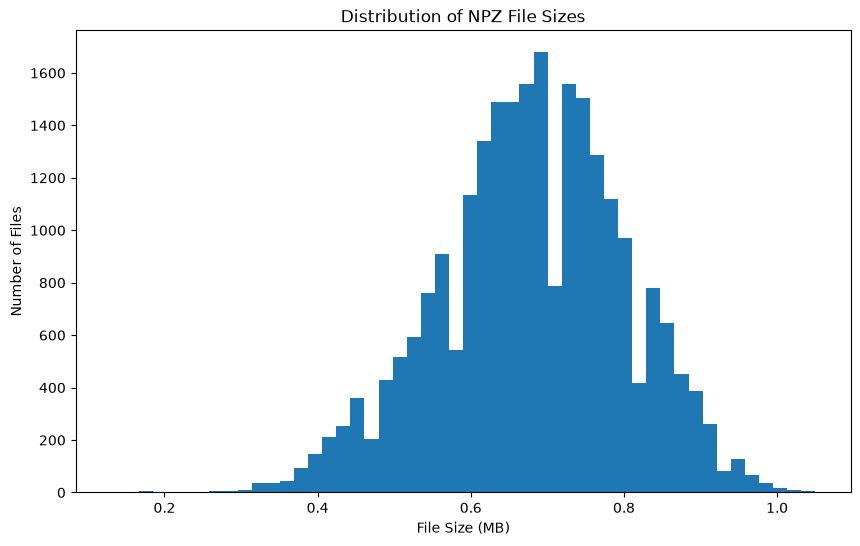

In [22]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["file_size_mb"],
    bins=50
)

plt.xlabel("File Size (MB)")
plt.ylabel("Number of Files")
plt.title("Distribution of NPZ File Sizes")

plt.show()

C:\Users\SPADE\AppData\Local\Temp\ipykernel_35828\1316171457.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


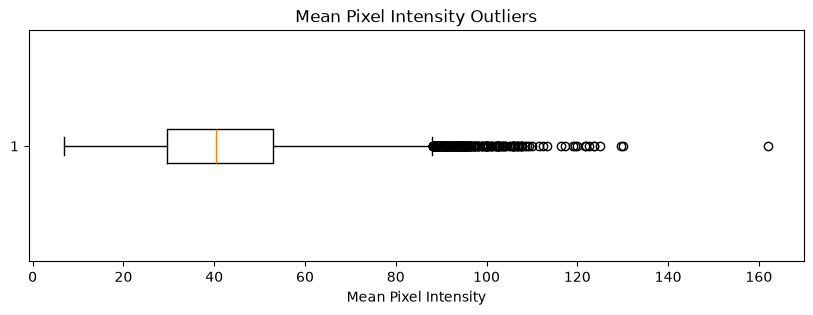

In [23]:
plt.figure(figsize=(10, 3))

plt.boxplot(
    df["mean_pixel"],
    vert=False
)

plt.xlabel("Mean Pixel Intensity")
plt.title("Mean Pixel Intensity Outliers")

plt.show()

In [24]:
Q1 = df["mean_pixel"].quantile(0.25)
Q3 = df["mean_pixel"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["mean_pixel"] < lower) |
    (df["mean_pixel"] > upper)
].copy()

print("Lower threshold:", lower)
print("Upper threshold:", upper)
print("Possible outliers:", len(outliers))
print("Percentage:", len(outliers) / len(df) * 100)

Lower threshold: -5.354920056401454
Upper threshold: 88.1015714269106
Possible outliers: 228
Percentage: 0.9355381395921382


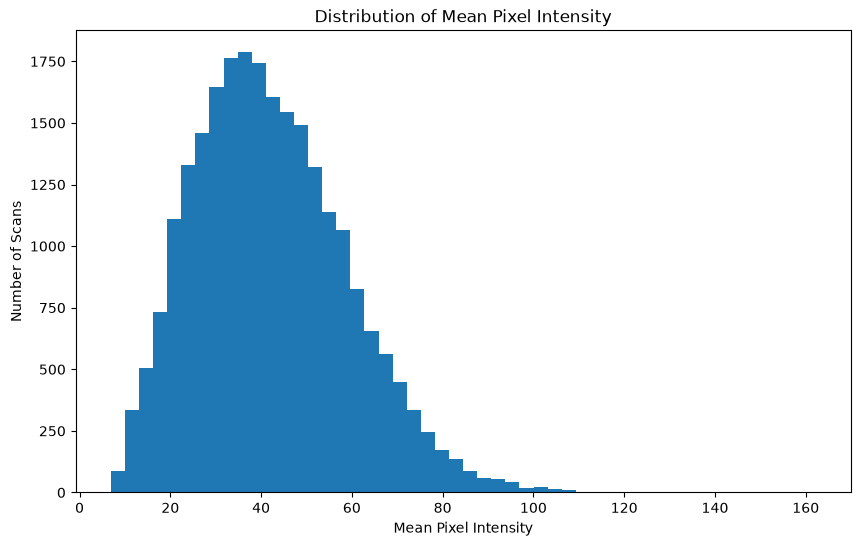

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df["mean_pixel"], bins=50)
plt.xlabel("Mean Pixel Intensity")
plt.ylabel("Number of Scans")
plt.title("Distribution of Mean Pixel Intensity")
plt.show()

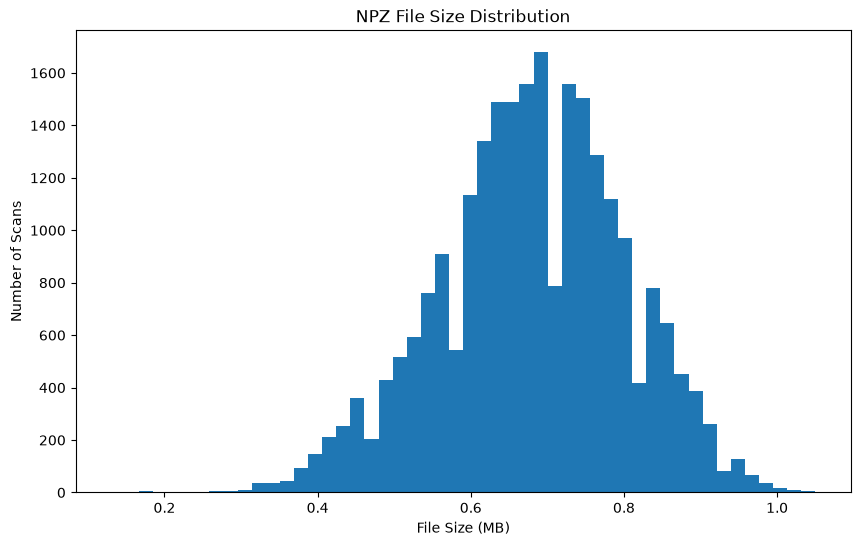

In [26]:
plt.figure(figsize=(10, 6))
plt.hist(df["file_size_mb"], bins=50)
plt.xlabel("File Size (MB)")
plt.ylabel("Number of Scans")
plt.title("NPZ File Size Distribution")
plt.show()

C:\Users\SPADE\AppData\Local\Temp\ipykernel_35828\3950886504.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["mean_pixel"], vert=False)


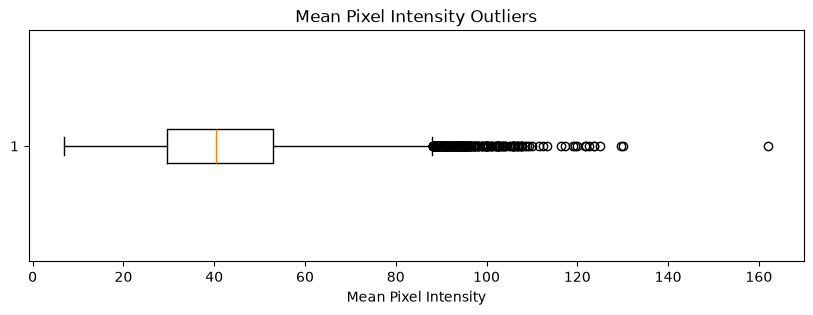

In [27]:
plt.figure(figsize=(10, 3))
plt.boxplot(df["mean_pixel"], vert=False)
plt.xlabel("Mean Pixel Intensity")
plt.title("Mean Pixel Intensity Outliers")
plt.show()

In [28]:
darkest = df.nsmallest(5, "mean_pixel")
brightest = df.nlargest(5, "mean_pixel")

print("Darkest:")
print(darkest[["filename", "mean_pixel"]])

print("\nBrightest:")
print(brightest[["filename", "mean_pixel"]])

Darkest:
                                                filename  mean_pixel
11220  1.2.826.0.1.3680043.8.498.35917065377312667007...    6.898452
22329  1.2.826.0.1.3680043.8.498.89837873571047667182...    7.064553
13114  1.2.826.0.1.3680043.8.498.45124382377451388384...    7.183845
22941  1.2.826.0.1.3680043.8.498.92800012200199889737...    7.216564
145    1.2.826.0.1.3680043.8.498.10068571245104766581...    7.426549

Brightest:
                                                filename  mean_pixel
10809  1.2.826.0.1.3680043.8.498.33768242062565931148...  162.121663
5672   1.2.826.0.1.3680043.8.498.12869397676148451644...  130.159078
19476  1.2.826.0.1.3680043.8.498.75940149982100115964...  129.552461
14692  1.2.826.0.1.3680043.8.498.52753180293233746385...  124.985552
21957  1.2.826.0.1.3680043.8.498.87918729980231637897...  123.667298


In [29]:
df.to_csv("dataset_report.csv", index=False)
outliers.to_csv("possible_outliers.csv", index=False)

In [31]:
import os

project_dir = r"C:\Users\SPADE\Documents\medical-image-quality-analysis"

folders = [
    project_dir,
    os.path.join(project_dir, "reports"),
    os.path.join(project_dir, "images"),
    os.path.join(project_dir, "notebooks"),
    os.path.join(project_dir, "src"),
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project created at:")
print(project_dir)

Project created at:
C:\Users\SPADE\Documents\medical-image-quality-analysis


In [32]:
df.to_csv(
    r"C:\Users\SPADE\Documents\medical-image-quality-analysis\reports\dataset_report.csv",
    index=False
)

print("Dataset report saved!")

Dataset report saved!


In [34]:
outliers.to_csv(
    r"C:\Users\SPADE\Documents\medical-image-quality-analysis\reports\possible_outliers.csv",
    index=False
)

In [2]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\SPADE
['.anaconda', '.arduinoIDE', '.conda', '.continuum', '.ipynb_checkpoints', '.ipython', '.jupyter', '.lim', '.limpc', '.m2', '.matplotlib', '.memestra', '.ms-ad', '.nbi', '.openjfx', '.packettracer', '.vscode', '3D Objects', 'antiRecoil', 'AppData', 'Application Data', 'Cisco Packet Tracer 8.2.2', 'Contacts', 'Cookies', 'dataset_analysis.ipynb', 'dataset_report.csv', 'Desktop', 'Documents', 'Downloads', 'EDynamics.exe', 'Favorites', 'IntelGraphicsProfiles', 'Links', 'Local Settings', 'MicrosoftEdgeBackups', 'miniconda3', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{c60dcc59-7525-11f0-8aed-c03c92a4d494}.TM.blf', 'NTUSER.DAT{c60dcc59-7525-11f0-8aed-c03c92a4d494}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{c60dcc59-7525-11f0-8aed-c03c92a4d494}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'Pictures', 'possible_outliers.csv', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SendTo

In [3]:
!cd

C:\Users\SPADE


In [4]:
from pathlib import Path

for file in Path.cwd().glob("*.ipynb"):
    print(file)

C:\Users\SPADE\dataset_analysis.ipynb
C:\Users\SPADE\Untitled.ipynb
C:\Users\SPADE\Untitled1.ipynb
